In [1]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [2]:
SEED = 42
PLOT_DPI = 100

# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_fe_train.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_adasyn_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_reg_ya1_fe.csv"
TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_cwgan_reg_ya1_500_fe.csv"

TEST_DATA_FILE = "../data/preprocessed_skab_dataset_fe_test.csv"

USE_LDA = False
USE_FE = True

In [3]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
# dataframe_train.set_index(pd.to_datetime(dataframe_train.datetime), drop=True, inplace=True)
# dataframe_train.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_train = dataframe_train.drop(columns=[col for col in dataframe_train.columns if col not in og_columns])

dataframe_train.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,59.9847,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604,0.0,No Anomaly
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,43.8822,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869,0.0,No Anomaly
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,58.5997,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483,0.0,No Anomaly
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,57.3947,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640,0.0,No Anomaly
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,65.1049,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654,0.0,No Anomaly


In [4]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
# dataframe_test.set_index(pd.to_datetime(dataframe_test.datetime), drop=True, inplace=True)
# dataframe_test.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_test = dataframe_test.drop(columns=[col for col in dataframe_test.columns if col not in og_columns])

dataframe_test.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,description,anomaly
0,0.210323,0.262893,2.65864,1.074847,88.6217,29.3147,230.091,126.677,86.544624,0.008485,...,59.3070,226.931105,519.969766,0.436431,0.800033,0.000436,0.170436,0.007359,No Anomaly,0.0
1,0.028297,0.042536,0.81412,0.745430,68.0318,24.2354,232.174,32.000,285.184002,0.023295,...,43.7964,39.756362,160.664872,0.247449,0.665238,0.000038,0.423439,0.005650,No Anomaly,0.0
2,0.028185,0.041387,0.81061,1.073357,68.8750,24.7075,208.422,32.000,257.117479,0.033542,...,44.1675,57.245837,143.606614,0.398630,0.681015,0.000036,0.479609,0.009025,No Anomaly,0.0
3,0.027955,0.042217,1.12593,1.073357,68.9973,24.7679,235.556,27.000,209.210164,0.039754,...,44.2294,48.301175,225.436632,0.214256,0.662168,0.000044,0.306061,0.004844,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.65451,1.402774,90.2739,27.8473,225.678,123.668,85.016820,0.011343,...,62.4266,289.130998,509.204832,0.567809,0.778314,0.000466,0.177284,0.009096,No Anomaly,0.0


In [5]:
scaler = StandardScaler()

values = scaler.fit_transform(dataframe_train.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    lda = LinearDiscriminantAnalysis()
    values = lda.fit_transform(values, dataframe_train.anomaly.to_numpy().ravel())
    dataframe_train_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_train_scaled = pd.DataFrame(values, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)

dataframe_train_scaled = dataframe_train_scaled.assign(anomaly=dataframe_train.anomaly.values, description=dataframe_train.description.values)
dataframe_train_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.336721,-0.378317,1.735285,-0.416311,0.734509,0.139275,-0.118832,0.702659,-0.961892,-0.363348,...,0.812219,0.515366,1.677213,-0.322756,0.473219,-0.491161,-1.047013,-0.509277,0.0,No Anomaly
1,-1.301046,-1.383375,-1.052788,2.638379,-2.176331,-1.281673,3.228995,-1.501399,0.864623,0.935144,...,-1.966696,-1.238319,-0.840624,-1.127417,-0.530677,-0.699392,-0.060543,-0.750385,0.0,No Anomaly
2,-0.364647,-0.411780,0.389960,5.720947,0.642906,0.393981,-0.030655,0.702659,-0.467750,-0.166267,...,0.573200,2.133150,0.372127,2.304950,0.488868,-0.503035,-0.390883,2.076283,0.0,No Anomaly
3,-0.156187,-0.256012,1.783553,-0.416311,0.345452,0.098603,0.801282,0.679217,-0.942664,-0.360785,...,0.365246,0.494490,1.841848,-0.410210,0.771536,-0.425085,-1.169514,-0.497597,0.0,No Anomaly
4,-1.031746,-0.993970,-0.819089,-3.610622,0.493849,-2.177696,1.122044,-0.469469,0.450037,-0.322801,...,1.695846,-1.038972,-0.734147,-0.863768,-0.783225,-0.649961,0.616055,-1.149367,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
312020,-0.256045,-0.277507,0.815000,0.540174,0.185226,0.534564,-0.992493,0.728285,-0.695977,-0.335652,...,-0.047995,0.792487,0.687055,0.507710,0.415350,-0.456464,-0.680630,0.540508,7.0,Sharp Water Increase (Circuit)
312021,-0.257871,-0.267630,0.884507,0.543066,0.176837,0.535753,-1.030866,0.726446,-0.724223,-0.335345,...,-0.058678,0.791461,0.749398,0.461510,0.366528,-0.454718,-0.717002,0.496604,7.0,Sharp Water Increase (Circuit)
312022,-0.259542,-0.270348,0.852597,0.529988,0.177206,0.541601,-1.039903,0.728130,-0.712493,-0.335958,...,-0.061194,0.789627,0.717971,0.482136,0.370120,-0.455780,-0.699555,0.518671,7.0,Sharp Water Increase (Circuit)
312023,-0.258995,-0.277142,0.844187,0.546789,0.181926,0.538531,-1.022339,0.727679,-0.708527,-0.335370,...,-0.053969,0.793654,0.711798,0.490887,0.400511,-0.456985,-0.695187,0.525235,7.0,Sharp Water Increase (Circuit)


In [6]:
values = scaler.transform(dataframe_test.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    values = lda.transform(values)
    dataframe_test_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_test_scaled = pd.DataFrame(values, columns=dataframe_test.drop(columns=["anomaly", "description"]).columns)

dataframe_test_scaled = dataframe_test_scaled.assign(anomaly=dataframe_test.anomaly.values, description=dataframe_test.description.values)
dataframe_test_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.383443,-0.396927,1.167858,-0.416311,0.692161,0.269782,0.383579,0.695087,-0.768739,-0.362525,...,0.695264,0.508623,1.180114,-0.088823,0.326550,-0.503528,-0.840871,-0.261582,0.0,No Anomaly
1,-1.300684,-1.381535,-2.171638,-3.498879,-2.264559,-1.461887,0.763856,-1.524384,3.048071,0.202660,...,-1.981503,-1.672636,-2.106557,-1.186118,-0.562321,-0.698628,2.499406,-0.822363,0.0,No Anomaly
2,-1.301248,-1.386672,-2.177993,-0.430250,-2.143475,-1.300935,-3.572364,-1.524384,2.508779,0.593744,...,-1.917460,-1.468821,-2.262594,-0.308313,-0.458284,-0.699196,3.240987,0.285313,0.0,No Anomaly
3,-1.302408,-1.382962,-1.607107,-0.430250,-2.125913,-1.280343,1.381282,-1.641597,1.588251,0.830795,...,-1.906777,-1.573058,-1.514070,-1.378847,-0.582563,-0.695646,0.949714,-1.086789,12.0,Inlet Valve Malfunction
4,-0.376257,-0.355962,1.160381,2.652318,0.929418,-0.230494,-0.422068,0.624549,-0.798095,-0.253450,...,1.233634,1.233476,1.081644,0.673998,0.183334,-0.489173,-0.750463,0.308356,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,-1.306617,-1.393794,-1.570807,-0.430250,-2.037139,-1.208306,0.426116,-1.547827,1.430193,0.635037,...,-1.836556,-1.489668,-1.523966,-1.187656,-0.454991,-0.699998,1.005580,-0.859198,12.0,Inlet Valve Malfunction
7377,-0.388920,-0.403835,0.939301,-0.416311,0.744044,0.221916,-0.928861,0.679217,-0.740389,-0.360785,...,0.781846,0.494490,0.812719,0.108626,0.330331,-0.504746,-0.642567,-0.095256,0.0,No Anomaly
7378,-1.304718,-1.394189,-2.524934,-0.430250,-2.224480,-1.372530,0.185864,-1.523641,4.677314,0.592477,...,-1.978569,-1.468160,-2.474057,0.138504,-0.382376,-0.700355,4.394070,0.885627,0.0,No Anomaly
7379,-0.218384,-0.287558,0.556037,2.652318,0.251078,0.328148,4.043588,0.711661,-0.360599,-0.266078,...,0.135632,1.334721,0.937302,0.881666,0.628844,-0.448801,-0.802004,0.856433,0.0,No Anomaly


In [7]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    # if i[0] == 0: continue
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]
# anomaly_ids

In [8]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

### K-Means

In [9]:
dataframe_data = dataframe_train_scaled.drop(columns=["description"])

kmeans_custom = KMeans(n_clusters=len(dataframe_data.anomaly.unique()), random_state=SEED) # n_init=1 when pre-defined
dataframe_X = dataframe_data.drop(columns=["anomaly"])
kmeans_custom.fit(dataframe_X.values)

KMeans(n_clusters=14, random_state=42)

In [10]:
unique_values, counts = np.unique(kmeans_custom.labels_, return_counts=True)

for value, count in zip(unique_values, counts):
    print(f"{value} occurs {count} times")

0 occurs 22519 times
1 occurs 41106 times
2 occurs 24187 times
3 occurs 48203 times
4 occurs 23 times
5 occurs 22184 times
6 occurs 4644 times
7 occurs 44202 times
8 occurs 22171 times
9 occurs 23283 times
10 occurs 7691 times
11 occurs 28366 times
12 occurs 32 times
13 occurs 23414 times


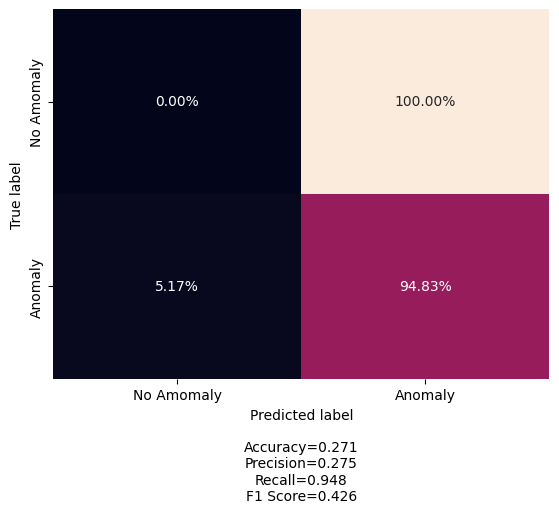

In [11]:
dataframe_data = dataframe_test_scaled.drop(columns=["anomaly", "description"])

plot.make_confusion_matrix(
    format_cf(confusion_matrix(dataframe_test_scaled.anomaly.values, kmeans_custom.predict(dataframe_data.values))),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [12]:
# plot.make_confusion_matrix(
#     confusion_matrix(dataframe_train_scaled.anomaly.values, kmeans_custom.labels_),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

### Isolation Forest

In [13]:
dataframe_X_train = dataframe_train_scaled.drop(columns=["anomaly", "description"])
dataframe_y_train = dataframe_train_scaled[["anomaly"]]
dataframe_X_test = dataframe_test_scaled.drop(columns=["anomaly", "description"])
dataframe_y_test = dataframe_test_scaled[["anomaly"]]

In [14]:
# dataframe_X = dataframe.drop(columns=["anomaly", "description"])
# dataframe_y = dataframe[["anomaly"]]

# X_train, X_test, y_train, y_test = train_test_split(
#                                                         dataframe_X.values, 
#                                                         dataframe_y.values.ravel(), 
#                                                         test_size=0.3, 
#                                                         random_state=SEED, 
#                                                         stratify=dataframe_y.values.ravel()
# )
# dataframe_X_train = pd.DataFrame(X_train, columns=dataframe_X.columns)
# dataframe_X_test = pd.DataFrame(X_test, columns=dataframe_X.columns)
# dataframe_y_train = pd.DataFrame(y_train, columns=dataframe_y.columns)
# dataframe_y_test = pd.DataFrame(y_test, columns=dataframe_y.columns)

In [15]:
def train_evaluate_isolation_forest(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    contamination: float = 0.01, # Proportion of outliers in the data set
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates an Isolation Forest model for anomaly detection.
    """
    print(f"  Training Isolation Forest with contamination={contamination}...")
    model = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1)
    model.fit(X_train)

    # Isolation Forest provides a decision_function where lower is more anomalous
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for anomaly, -1 for normal by IsolationForest, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  Isolation Forest trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [16]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_isolation_forest(dataframe_X_train, dataframe_X_test, contamination=0.3, random_state=SEED)

  Training Isolation Forest with contamination=0.3...
  Isolation Forest trained. Detected 6677 anomalies in test set.


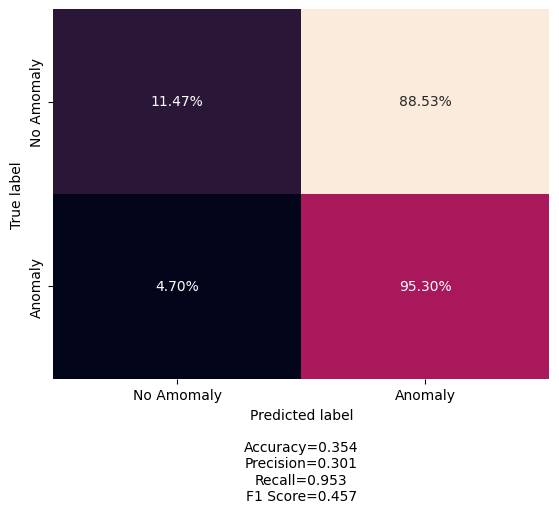

In [17]:
# y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
# y.fillna(0, inplace=True)
# plot.make_confusion_matrix(
#     confusion_matrix(y, train_labels),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### One Class SVM

In [18]:
def train_evaluate_one_class_svm(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    nu: float = 0.01, # An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
    kernel: str = 'rbf',
    gamma: str = 'scale'
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates a One-Class SVM model for anomaly detection.
    """
    print(f"  Training One-Class SVM with nu={nu}, kernel={kernel}...")
    model = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
    model.fit(X_train)

    # One-Class SVM provides a decision_function where higher is more normal
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for normal, -1 for outlier by OCSVM, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  One-Class SVM trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [19]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_one_class_svm(dataframe_X_train, dataframe_X_test)

  Training One-Class SVM with nu=0.01, kernel=rbf...
  One-Class SVM trained. Detected 1112 anomalies in test set.


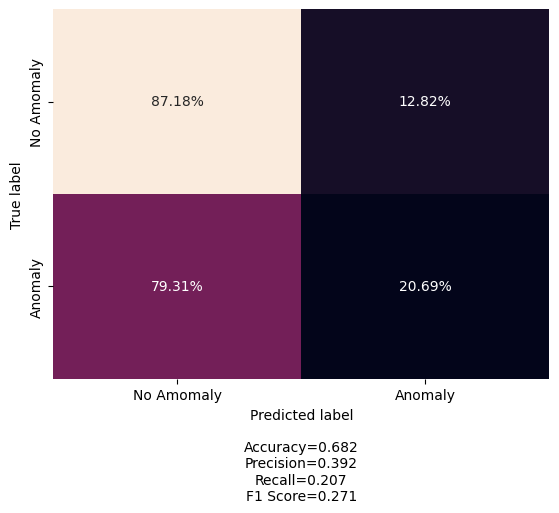

In [20]:
# y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
# y.fillna(0, inplace=True)
# plot.make_confusion_matrix(
#     confusion_matrix(y, train_labels),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)